
# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

**Aim:** Implement a Multi-Layer Perceptron (MLP) to learn the non-linear XOR Boolean function using Keras and TensorFlow.

The notebook uses the four XOR input combinations and trains a small neural network with:
- Input layer: 2 neurons
- Hidden layer: 4 neurons with Tanh activation
- Output layer: 1 neuron with Sigmoid activation
- Binary Cross-Entropy loss
- Adam optimizer


## 1. Import Libraries

In [6]:

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

np.random.seed(42)
tf.random.set_seed(42)


## 2. Create the XOR Dataset

In [7]:

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

print("Input (X):")
print(X)

print("\nOutput (y):")
print(y)


Input (X):
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output (y):
[[0.]
 [1.]
 [1.]
 [0.]]


## 3. Implement XOR Using Keras

In [8]:

model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(4, activation="tanh"),
    keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Train the Keras Model

In [9]:

history = model.fit(
    X, y,
    epochs=500,
    verbose=0
)

print("Training completed.")


Training completed.


## 5. Evaluate the Keras Model

In [10]:

predictions = model.predict(X, verbose=0)
predicted_classes = (predictions >= 0.5).astype(int)

print("XOR Predictions:")
for i in range(len(X)):
    print(
        f"Input: {X[i].astype(int)}  "
        f"Actual: {int(y[i][0])}  "
        f"Predicted probability: {predictions[i][0]:.4f}  "
        f"Predicted class: {predicted_classes[i][0]}"
    )

loss, accuracy = model.evaluate(X, y, verbose=0)
print(f"\nFinal Accuracy: {accuracy * 100:.2f}%")


XOR Predictions:
Input: [0 0]  Actual: 0  Predicted probability: 0.0119  Predicted class: 0
Input: [0 1]  Actual: 1  Predicted probability: 0.9942  Predicted class: 1
Input: [1 0]  Actual: 1  Predicted probability: 0.9759  Predicted class: 1
Input: [1 1]  Actual: 0  Predicted probability: 0.0311  Predicted class: 0

Final Accuracy: 100.00%


## 6. Training Curve

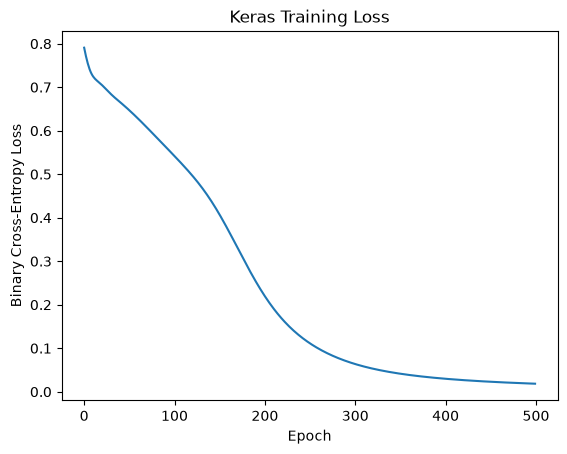

In [11]:

plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Keras Training Loss")
plt.show()



## 7. Effect of Number of Hidden Neurons

The XOR problem requires a non-linear hidden layer. We can change the number of hidden neurons and observe the final accuracy.


In [12]:

for neurons in [2, 4, 8]:
    test_model = keras.Sequential([
        keras.layers.Input(shape=(2,)),
        keras.layers.Dense(neurons, activation="tanh"),
        keras.layers.Dense(1, activation="sigmoid")
    ])

    test_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    test_model.fit(X, y, epochs=500, verbose=0)
    _, acc = test_model.evaluate(X, y, verbose=0)

    print(f"Hidden neurons: {neurons}, Accuracy: {acc * 100:.2f}%")


Hidden neurons: 2, Accuracy: 100.00%
Hidden neurons: 4, Accuracy: 100.00%
Hidden neurons: 8, Accuracy: 100.00%


## 8. Implement XOR Using TensorFlow Low-Level API

In [13]:

# Model parameters
W1 = tf.Variable(tf.random.normal([2, 4]), dtype=tf.float32)
b1 = tf.Variable(tf.zeros([4]), dtype=tf.float32)

W2 = tf.Variable(tf.random.normal([4, 1]), dtype=tf.float32)
b2 = tf.Variable(tf.zeros([1]), dtype=tf.float32)

learning_rate = 0.01
optimizer = tf.optimizers.Adam(learning_rate=learning_rate)

def forward_pass(X):
    hidden = tf.tanh(tf.matmul(X, W1) + b1)
    output = tf.sigmoid(tf.matmul(hidden, W2) + b2)
    return output

def loss_function(y_true, y_pred):
    return tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(y_true, y_pred)
    )


## 9. Train the TensorFlow Model

In [14]:

loss_history = []

for epoch in range(500):
    with tf.GradientTape() as tape:
        y_pred = forward_pass(X)
        loss = loss_function(y, y_pred)

    variables = [W1, b1, W2, b2]
    gradients = tape.gradient(loss, variables)
    optimizer.apply_gradients(zip(gradients, variables))

    loss_history.append(float(loss))

print("Training completed.")


Training completed.


## 10. Evaluate the TensorFlow Model

In [15]:

tf_predictions = forward_pass(X).numpy()
tf_classes = (tf_predictions >= 0.5).astype(int)

print("XOR Predictions:")
for i in range(len(X)):
    print(
        f"Input: {X[i].astype(int)}  "
        f"Actual: {int(y[i][0])}  "
        f"Predicted probability: {tf_predictions[i][0]:.4f}  "
        f"Predicted class: {tf_classes[i][0]}"
    )

tf_accuracy = np.mean(tf_classes == y)
print(f"\nFinal Accuracy: {tf_accuracy * 100:.2f}%")


XOR Predictions:
Input: [0 0]  Actual: 0  Predicted probability: 0.0031  Predicted class: 0
Input: [0 1]  Actual: 1  Predicted probability: 0.9574  Predicted class: 1
Input: [1 0]  Actual: 1  Predicted probability: 0.9916  Predicted class: 1
Input: [1 1]  Actual: 0  Predicted probability: 0.0382  Predicted class: 0

Final Accuracy: 100.00%


## 11. TensorFlow Training Curve

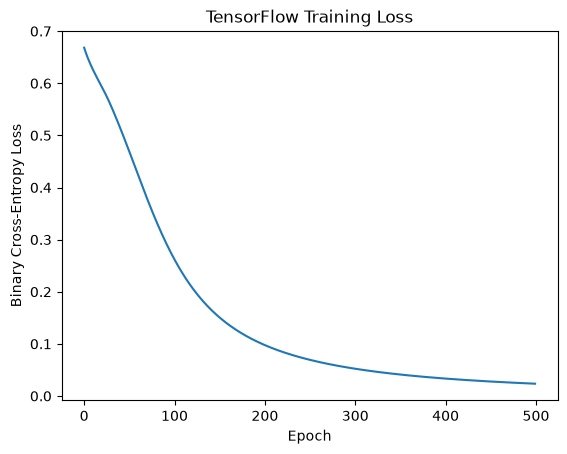

In [16]:

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("TensorFlow Training Loss")
plt.show()



## 12. Result and Conclusion

The MLP successfully learned the XOR Boolean function using both Keras and the TensorFlow low-level API. Both implementations correctly classified all four XOR input combinations and achieved a final accuracy of 100%.

The experiment demonstrates that XOR cannot be learned using a single linear layer because it is a non-linear problem. A hidden layer with a non-linear activation function such as Tanh enables the network to learn the required decision boundary.

The experiment with different numbers of hidden neurons showed that 2, 4, and 8 hidden neurons all achieved 100% accuracy on the XOR dataset. The training curves also showed that the Binary Cross-Entropy loss decreased progressively during training.

Therefore, the MLP successfully learned the XOR Boolean function, and the experiment demonstrated the effect of the network architecture and training parameters on learning performance.